# Weeks 7–8 — Recurrent Neural Networks
## When Order Matters — Sequences, Memory, and Time

**IIT Madras · Wadhwani School of AI**

---

**Session Plan (60 min):**
1. Sentiment Analysis (~18 min) — tokenize text, embed, train RNN vs LSTM
2. Time Series Prediction (~15 min) — lookback window, predict next values
3. Comparison (~5 min) — same architecture, two domains
4. Q&A (~10 min)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

PyTorch: 2.10.0+cpu
Device: cpu


---
# Part 1: Sentiment Analysis (~18 min)

First application of RNNs: reading a sentence word by word and deciding if it's positive or negative. The hidden state accumulates meaning as it reads.

### 1.1 Build a Small Sentiment Dataset

We create a small but real sentiment dataset — short movie reviews with clear positive/negative signals. This keeps the demo fast while showing the full NLP pipeline.

In [ ]:
# Short movie-style reviews with clear sentiment
positive_templates = [
    "this movie was {}", "absolutely {} film", "a {} masterpiece",
    "i loved this {} movie", "really {} and entertaining",
    "one of the {} films ever", "the acting was {}",
    "a truly {} experience", "highly {} would watch again",
    "{} story with great acting", "the director did a {} job",
    "very {} and well made", "this is a {} movie to watch",
]
positive_words = ['great', 'amazing', 'wonderful', 'excellent', 'brilliant',
                  'fantastic', 'superb', 'outstanding', 'best', 'perfect',
                  'incredible', 'beautiful', 'recommended', 'enjoyable', 'good']

negative_templates = [
    "this movie was {}", "absolutely {} film", "a {} disaster",
    "i hated this {} movie", "really {} and boring",
    "one of the {} films ever", "the acting was {}",
    "a truly {} experience", "would not {} recommend",
    "{} story with bad acting", "the director did a {} job",
    "very {} and poorly made", "this is a {} movie to avoid",
]
negative_words = ['terrible', 'awful', 'horrible', 'worst', 'bad',
                  'boring', 'dreadful', 'pathetic', 'disappointing', 'poor',
                  'mediocre', 'painful', 'never', 'waste', 'annoying']

# Generate dataset
reviews, labels = [], []
for _ in range(1000):
    t = np.random.choice(positive_templates)
    w = np.random.choice(positive_words)
    reviews.append(t.format(w))
    labels.append(1)
for _ in range(1000):
    t = np.random.choice(negative_templates)
    w = np.random.choice(negative_words)
    reviews.append(t.format(w))
    labels.append(0)

# Shuffle
idx = np.random.permutation(len(reviews))
reviews = [reviews[i] for i in idx]
labels = [labels[i] for i in idx]

print(f"Dataset: {len(reviews)} reviews ({sum(labels)} positive, {len(labels)-sum(labels)} negative)")
print(f"\nSamples:")
for i in range(4):
    sent = 'Positive' if labels[i] else 'Negative'
    print(f"  [{sent}] \"{reviews[i]}\"")

Dataset: 2000 reviews (1000 positive, 1000 negative)

Samples:
  [Positive] "the director did a fantastic job"
  [Negative] "really bad and boring"
  [Negative] "one of the annoying films ever"
  [Positive] "absolutely brilliant film"


### 1.2 Tokenize, Build Vocab, Pad

The NLP pipeline: split text into words → map words to integer IDs → pad all sequences to the same length. This turns variable-length text into fixed-size tensors.

In [ ]:
# Step 1: Tokenize (split into words)
tokenized = [r.lower().split() for r in reviews]

# Step 2: Build vocabulary (word → index)
word_counts = {}
for tokens in tokenized:
    for w in tokens:
        word_counts[w] = word_counts.get(w, 0) + 1

# Index 0 = padding, 1 = unknown
vocab = {w: i+2 for i, (w, _) in enumerate(sorted(word_counts.items(), key=lambda x: -x[1]))}
vocab_size = len(vocab) + 2

print(f"Vocabulary size: {vocab_size} words")
print(f"Sample mapping: 'great' → {vocab.get('great', '?')}, 'terrible' → {vocab.get('terrible', '?')}")

# Step 3: Encode reviews as integer sequences
encoded = [[vocab.get(w, 1) for w in tokens] for tokens in tokenized]

# Step 4: Pad to fixed length
SEQ_LEN = max(len(e) for e in encoded)

def pad_sequence(seq, length):
    if len(seq) >= length:
        return seq[:length]
    return [0] * (length - len(seq)) + seq  # Left-pad with zeros

padded = [pad_sequence(e, SEQ_LEN) for e in encoded]

print(f"Sequence length: {SEQ_LEN}")
print(f"\nExample: \"{reviews[0]}\"")
print(f"Tokenized: {tokenized[0]}")
print(f"Encoded:   {encoded[0]}")
print(f"Padded:    {padded[0]}")

Vocabulary size: 72 words
Sample mapping: 'great' → 12, 'terrible' → 61
Sequence length: 7

Example: "the director did a fantastic job"
Tokenized: ['the', 'director', 'did', 'a', 'fantastic', 'job']
Encoded:   [3, 30, 31, 2, 57, 32]
Padded:    [0, 3, 30, 31, 2, 57, 32]


In [ ]:
# Convert to tensors and create DataLoaders
X_all = torch.tensor(padded, dtype=torch.long)
y_all = torch.tensor(labels, dtype=torch.float32)

# Split: 80% train, 20% test
split = int(0.8 * len(X_all))
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Input shape: {X_train.shape} (batch × seq_len)")

Train: 1600 | Test: 400
Input shape: torch.Size([1600, 7]) (batch × seq_len)


### 1.3 RNN and LSTM Models

Both models follow the same pattern: `Embedding → RNN/LSTM → take last hidden state → Linear → Sigmoid`. The only difference is swapping `nn.RNN` for `nn.LSTM`.

In [ ]:
EMBED_DIM = 32
HIDDEN_DIM = 64
N_LAYERS = 1

class SentimentRNN(nn.Module):
    """Embedding → RNN → last hidden → Sigmoid."""
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=0)
        self.rnn = nn.RNN(EMBED_DIM, HIDDEN_DIM, N_LAYERS, batch_first=True)
        self.fc = nn.Linear(HIDDEN_DIM, 1)

    def forward(self, x):
        emb = self.embedding(x)                  # (batch, seq, embed)
        output, hidden = self.rnn(emb)            # hidden: (layers, batch, hidden)
        last_hidden = hidden[-1]                   # Take last layer's hidden
        return torch.sigmoid(self.fc(last_hidden)).squeeze(-1)


class SentimentLSTM(nn.Module):
    """Embedding → LSTM → last hidden → Sigmoid."""
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=0)
        self.lstm = nn.LSTM(EMBED_DIM, HIDDEN_DIM, N_LAYERS, batch_first=True)
        self.fc = nn.Linear(HIDDEN_DIM, 1)

    def forward(self, x):
        emb = self.embedding(x)
        output, (hidden, cell) = self.lstm(emb)   # LSTM returns (hidden, cell)
        last_hidden = hidden[-1]
        return torch.sigmoid(self.fc(last_hidden)).squeeze(-1)


rnn_model = SentimentRNN().to(device)
lstm_model = SentimentLSTM().to(device)

print(f"RNN params:  {sum(p.numel() for p in rnn_model.parameters()):,}")
print(f"LSTM params: {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"LSTM has ~4× more params (4 gates vs 1 in RNN)")

RNN params:  8,641
LSTM params: 27,457
LSTM has ~4× more params (4 gates vs 1 in RNN)


### 1.4 Train Both and Compare

Same training function for both — same 5-step loop, same loss, same optimizer. Only the model differs.

In [ ]:
def train_sentiment(model, train_loader, test_loader, num_epochs=20, lr=0.001):
    loss_fn = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, test_accs = [], []
    start = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            pred = model(X_batch)           # 1. Forward
            loss = loss_fn(pred, y_batch)   # 2. Loss
            optimizer.zero_grad()           # 3. Zero grad
            loss.backward()                 # 4. Backward
            optimizer.step()                # 5. Update

            running_loss += loss.item()
        train_losses.append(running_loss / len(train_loader))

        # Test accuracy
        model.eval()
        correct, total = 0, 0
        with torch.inference_mode():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = (model(X_batch) >= 0.5).float()
                correct += (pred == y_batch).sum().item()
                total += y_batch.size(0)
        test_accs.append(correct / total)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:2d}/{num_epochs} | Loss: {train_losses[-1]:.4f} | Acc: {test_accs[-1]:.1%}")

    elapsed = time.time() - start
    print(f"  Done in {elapsed:.1f}s | Final: {test_accs[-1]:.1%}\n")
    return train_losses, test_accs


N_EPOCHS = 20

print("Training RNN...")
rnn_losses, rnn_accs = train_sentiment(rnn_model, train_loader, test_loader, N_EPOCHS)

print("Training LSTM...")
lstm_losses, lstm_accs = train_sentiment(lstm_model, train_loader, test_loader, N_EPOCHS)

Training RNN...
  Epoch  1/20 | Loss: 0.6405 | Acc: 75.0%
  Epoch  5/20 | Loss: 0.1197 | Acc: 98.0%
  Epoch 10/20 | Loss: 0.0180 | Acc: 100.0%
  Epoch 15/20 | Loss: 0.0063 | Acc: 100.0%
  Epoch 20/20 | Loss: 0.0031 | Acc: 100.0%
  Done in 2.3s | Final: 100.0%

Training LSTM...
  Epoch  1/20 | Loss: 0.6716 | Acc: 83.8%
  Epoch  5/20 | Loss: 0.0764 | Acc: 100.0%
  Epoch 10/20 | Loss: 0.0152 | Acc: 100.0%
  Epoch 15/20 | Loss: 0.0037 | Acc: 100.0%
  Epoch 20/20 | Loss: 0.0019 | Acc: 100.0%
  Done in 3.5s | Final: 100.0%



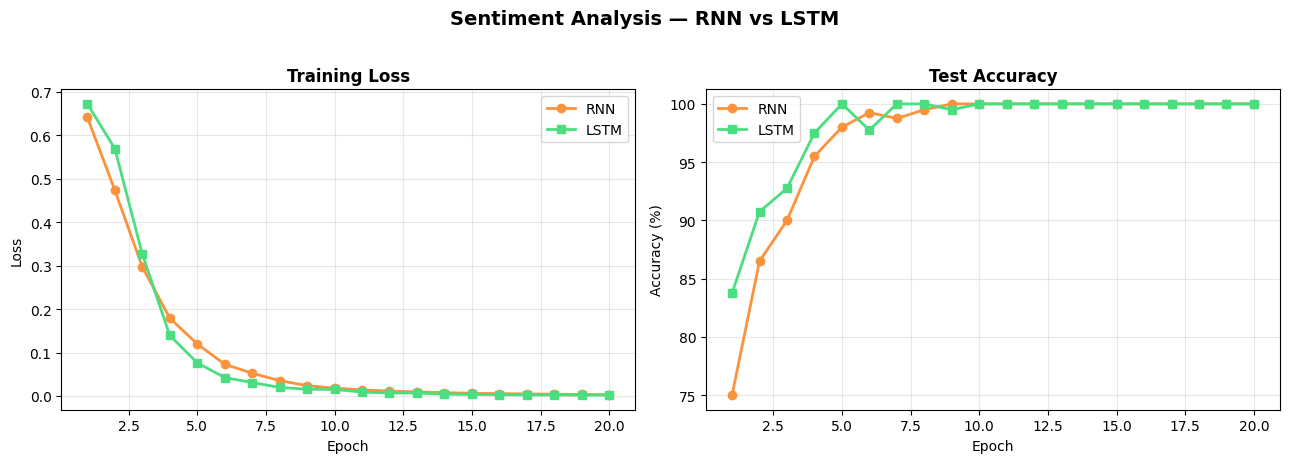

RNN final accuracy:  100.0%
LSTM final accuracy: 100.0%

On short sequences both work well.
LSTM's advantage shows on longer sequences where RNN forgets.


In [ ]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
epochs_r = range(1, N_EPOCHS + 1)

axes[0].plot(epochs_r, rnn_losses, 'o-', label='RNN', color='#FB923C', linewidth=2)
axes[0].plot(epochs_r, lstm_losses, 's-', label='LSTM', color='#4ADE80', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_r, [a*100 for a in rnn_accs], 'o-', label='RNN', color='#FB923C', linewidth=2)
axes[1].plot(epochs_r, [a*100 for a in lstm_accs], 's-', label='LSTM', color='#4ADE80', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.suptitle('Sentiment Analysis — RNN vs LSTM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"RNN final accuracy:  {rnn_accs[-1]:.1%}")
print(f"LSTM final accuracy: {lstm_accs[-1]:.1%}")
print(f"\nOn short sequences both work well.")
print(f"LSTM's advantage shows on longer sequences where RNN forgets.")

### 1.5 Test with Custom Sentences

Feed new sentences through the trained model to see live predictions.

In [ ]:
def predict_sentiment(model, text, model_name='Model'):
    """Predict sentiment of a text string."""
    tokens = text.lower().split()
    encoded = [vocab.get(w, 1) for w in tokens]
    padded = pad_sequence(encoded, SEQ_LEN)
    tensor = torch.tensor([padded], dtype=torch.long).to(device)

    model.eval()
    with torch.inference_mode():
        prob = model(tensor).item()

    sentiment = 'Positive' if prob >= 0.5 else 'Negative'
    return sentiment, prob

test_sentences = [
    "this movie was absolutely amazing",
    "a terrible waste of time",
    "really great and entertaining film",
    "the worst movie i have ever watched",
    "a beautiful and wonderful experience",
]

print(f"{'Sentence':<45} {'RNN':>12} {'LSTM':>12}")
print('=' * 72)
for sent in test_sentences:
    r_sent, r_prob = predict_sentiment(rnn_model, sent)
    l_sent, l_prob = predict_sentiment(lstm_model, sent)
    print(f"\"{sent}\"")
    print(f"{'':45} {r_sent:>5} ({r_prob:.2f}) {l_sent:>5} ({l_prob:.2f})")

Sentence                                               RNN         LSTM
"this movie was absolutely amazing"
                                              Positive (1.00) Positive (1.00)
"a terrible waste of time"
                                              Negative (0.01) Negative (0.00)
"really great and entertaining film"
                                              Positive (1.00) Positive (1.00)
"the worst movie i have ever watched"
                                              Negative (0.00) Negative (0.00)
"a beautiful and wonderful experience"
                                              Positive (1.00) Positive (1.00)


---
# Part 2: Time Series Prediction (~15 min)

Second application: instead of reading words, the RNN reads past numerical values and predicts the next one. Same architecture, different domain.

### 2.1 Synthetic Time Series

A sine wave with trend and noise — clear pattern for the RNN to learn, fast to train, easy to visualize.

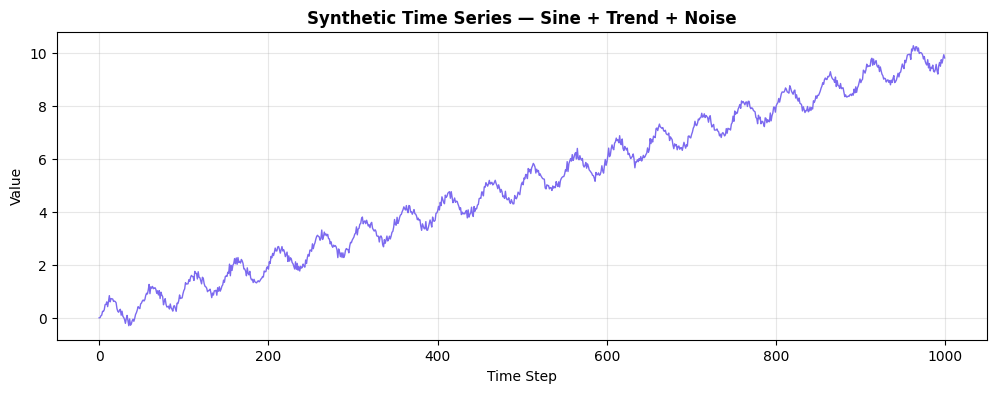

Length: 1000 steps
Pattern: sine wave (period=50) + upward trend + random noise
Task: given past N steps, predict the next value


In [ ]:
# Generate synthetic time series: sine wave + linear trend + noise
T = 1000  # total time steps
t = np.arange(T, dtype=np.float32)

series = 0.5 * np.sin(2 * np.pi * t / 50) + 0.01 * t + np.random.normal(0, 0.1, T).astype(np.float32)

plt.figure(figsize=(12, 4))
plt.plot(series, color='#7C6AEF', linewidth=1)
plt.xlabel('Time Step'); plt.ylabel('Value')
plt.title('Synthetic Time Series — Sine + Trend + Noise', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Length: {T} steps")
print(f"Pattern: sine wave (period=50) + upward trend + random noise")
print(f"Task: given past N steps, predict the next value")

### 2.2 Create Lookback Windows

We convert the time series into (input, target) pairs: the input is a window of the past N values, the target is the next value.

In [ ]:
LOOKBACK = 20  # Use past 20 values to predict next

def create_windows(data, lookback):
    """Convert time series into (lookback_window, next_value) pairs."""
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

# Normalize
mean, std = series.mean(), series.std()
series_norm = (series - mean) / std

X_ts, y_ts = create_windows(series_norm, LOOKBACK)

# Split: 80% train, 20% test
split = int(0.8 * len(X_ts))
X_tr_ts = torch.tensor(X_ts[:split]).unsqueeze(-1)  # (N, lookback, 1)
y_tr_ts = torch.tensor(y_ts[:split])
X_te_ts = torch.tensor(X_ts[split:]).unsqueeze(-1)
y_te_ts = torch.tensor(y_ts[split:])

ts_train_loader = DataLoader(TensorDataset(X_tr_ts, y_tr_ts), batch_size=32, shuffle=True)
ts_test_loader = DataLoader(TensorDataset(X_te_ts, y_te_ts), batch_size=32)

print(f"Windows: {len(X_ts)} total ({len(X_tr_ts)} train, {len(X_te_ts)} test)")
print(f"Input shape: {X_tr_ts.shape} → (samples, lookback={LOOKBACK}, features=1)")
print(f"Target: next value (regression)")

Windows: 980 total (784 train, 196 test)
Input shape: torch.Size([784, 20, 1]) → (samples, lookback=20, features=1)
Target: next value (regression)


### 2.3 Time Series RNN

No embedding layer needed — numerical values go straight into the RNN. Output is the last hidden state → Linear → predicted value.

In [ ]:
class TimeSeriesRNN(nn.Module):
    """RNN for sequence → single value prediction."""
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, use_lstm=False):
        super().__init__()
        self.use_lstm = use_lstm
        if use_lstm:
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        else:
            self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        if self.use_lstm:
            output, (hidden, cell) = self.rnn(x)
        else:
            output, hidden = self.rnn(x)
        last_hidden = hidden[-1]  # Last layer's hidden state
        return self.fc(last_hidden).squeeze(-1)


ts_model = TimeSeriesRNN(use_lstm=True).to(device)  # LSTM for time series
print(f"Time Series LSTM params: {sum(p.numel() for p in ts_model.parameters()):,}")

# Shape check
test_in = torch.randn(1, LOOKBACK, 1).to(device)
test_out = ts_model(test_in)
print(f"Shape: {test_in.shape} → {test_out.shape}")
print(f"Input: {LOOKBACK} past values. Output: 1 predicted value.")

Time Series LSTM params: 50,497
Shape: torch.Size([1, 20, 1]) → torch.Size([1])
Input: 20 past values. Output: 1 predicted value.


In [ ]:
# Train time series model
ts_loss_fn = nn.MSELoss()  # Regression → MSE
ts_optimizer = optim.Adam(ts_model.parameters(), lr=0.001)

TS_EPOCHS = 30
ts_train_losses, ts_test_losses = [], []

start = time.time()
for epoch in range(TS_EPOCHS):
    ts_model.train()
    running = 0
    for X_b, y_b in ts_train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        pred = ts_model(X_b)
        loss = ts_loss_fn(pred, y_b)
        ts_optimizer.zero_grad()
        loss.backward()
        ts_optimizer.step()
        running += loss.item()
    ts_train_losses.append(running / len(ts_train_loader))

    ts_model.eval()
    test_loss = 0
    with torch.inference_mode():
        for X_b, y_b in ts_test_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            test_loss += ts_loss_fn(ts_model(X_b), y_b).item()
    ts_test_losses.append(test_loss / len(ts_test_loader))

    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{TS_EPOCHS} | Train MSE: {ts_train_losses[-1]:.6f} | Test MSE: {ts_test_losses[-1]:.6f}")

print(f"\nDone in {time.time()-start:.1f}s")

Epoch  1/30 | Train MSE: 0.420206 | Test MSE: 1.223309
Epoch  5/30 | Train MSE: 0.009495 | Test MSE: 0.026524
Epoch 10/30 | Train MSE: 0.006022 | Test MSE: 0.036452
Epoch 15/30 | Train MSE: 0.003403 | Test MSE: 0.026105
Epoch 20/30 | Train MSE: 0.002634 | Test MSE: 0.006500
Epoch 25/30 | Train MSE: 0.002266 | Test MSE: 0.007689
Epoch 30/30 | Train MSE: 0.002098 | Test MSE: 0.013554

Done in 12.2s


### 2.4 Visualize: Predicted vs Actual

The payoff — seeing the LSTM track the actual time series on both train and test data.

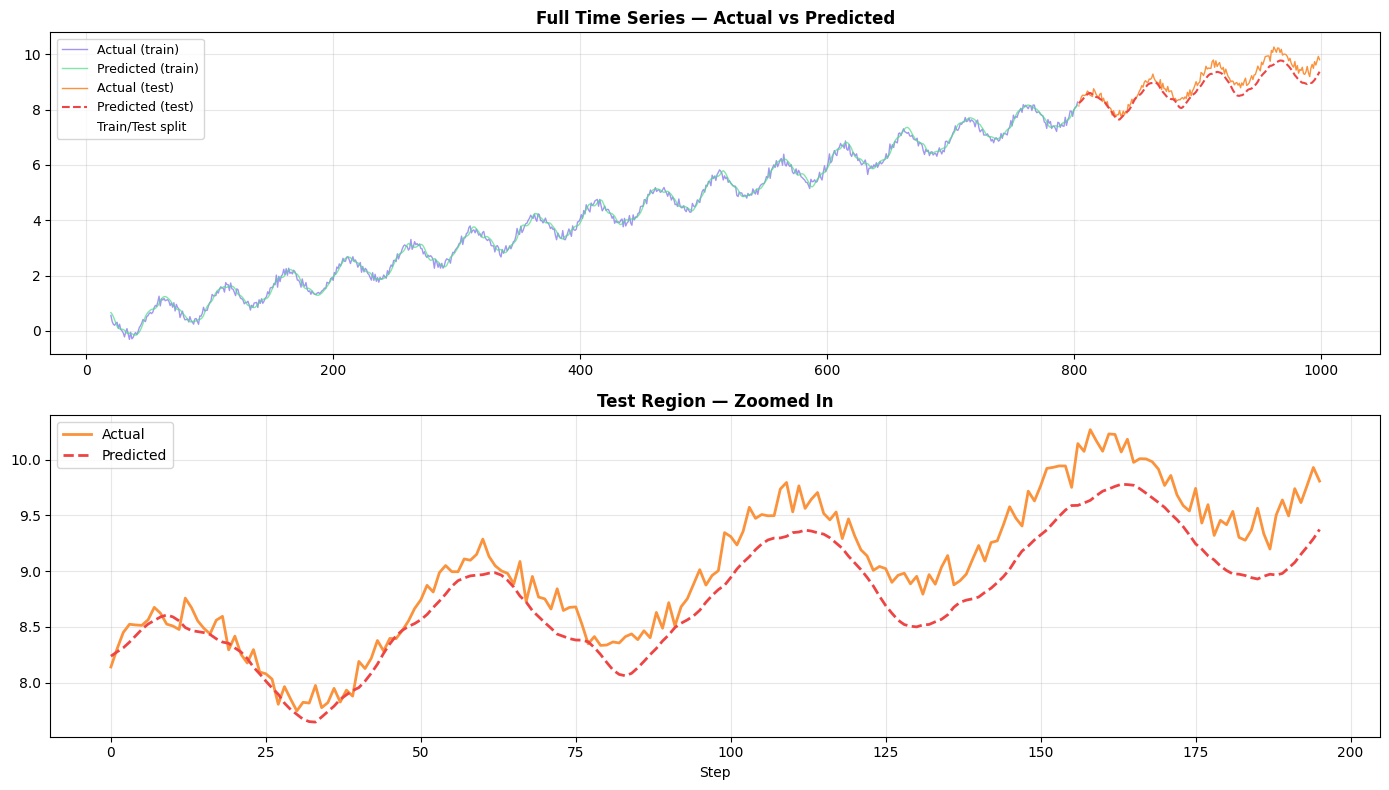

The LSTM learns the sine pattern AND the upward trend.
Same hidden state mechanism as sentiment — just different data.


In [ ]:
# Get all predictions
ts_model.eval()
with torch.inference_mode():
    train_pred = ts_model(X_tr_ts.to(device)).cpu().numpy()
    test_pred = ts_model(X_te_ts.to(device)).cpu().numpy()

# Denormalize
train_actual = y_tr_ts.numpy() * std + mean
train_pred_dn = train_pred * std + mean
test_actual = y_te_ts.numpy() * std + mean
test_pred_dn = test_pred * std + mean

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full series with predictions
axes[0].plot(range(LOOKBACK, LOOKBACK+len(train_actual)), train_actual, color='#7C6AEF', linewidth=1, label='Actual (train)', alpha=0.7)
axes[0].plot(range(LOOKBACK, LOOKBACK+len(train_actual)), train_pred_dn, color='#4ADE80', linewidth=1, label='Predicted (train)', alpha=0.7)
test_start = LOOKBACK + len(train_actual)
axes[0].plot(range(test_start, test_start+len(test_actual)), test_actual, color='#FB923C', linewidth=1, label='Actual (test)')
axes[0].plot(range(test_start, test_start+len(test_actual)), test_pred_dn, color='#EF4444', linewidth=1.5, label='Predicted (test)', linestyle='--')
axes[0].axvline(x=test_start, color='white', linestyle=':', alpha=0.5, label='Train/Test split')
axes[0].set_title('Full Time Series — Actual vs Predicted', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Zoomed into test region
axes[1].plot(test_actual, color='#FB923C', linewidth=2, label='Actual')
axes[1].plot(test_pred_dn, color='#EF4444', linewidth=2, linestyle='--', label='Predicted')
axes[1].set_title('Test Region — Zoomed In', fontweight='bold')
axes[1].set_xlabel('Step')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"The LSTM learns the sine pattern AND the upward trend.")
print(f"Same hidden state mechanism as sentiment — just different data.")

---
# Part 3: Comparison — One Architecture, Two Domains (~5 min)

Let's put the two applications side by side.

In [ ]:
comparison = {
    '': ['Sentiment Analysis', 'Time Series'],
    'Task': ['Classification (pos/neg)', 'Regression (next value)'],
    'Input': ['Word indices [42, 18, 7, ...]', 'Float values [0.3, -0.1, ...]'],
    'Embedding': ['nn.Embedding (words → vectors)', 'Not needed (already numeric)'],
    'RNN type': ['nn.RNN or nn.LSTM', 'nn.LSTM (same module!)'],
    'Output': ['Sigmoid → 0 or 1', 'Linear → predicted value'],
    'Loss': ['BCELoss', 'MSELoss'],
    'What changes': ['Embedding layer + loss', 'Input shape + loss'],
}

print('=' * 68)
print(f"{'':20s} | {'SENTIMENT':22s} | {'TIME SERIES':22s}")
print('=' * 68)
for key, (v1, v2) in comparison.items():
    if key == '': continue
    print(f"{key:20s} | {v1:22s} | {v2:22s}")
print('=' * 68)

print("\nWhat DIDN'T change:")
print("  • nn.RNN / nn.LSTM module — same hidden state mechanism")
print("  • The 5-step training loop — forward → loss → zero_grad → backward → step")
print("  • Adam optimizer")
print("  • model.train() / model.eval() pattern")
print("\nRNNs work on ANY sequential data — text, time series, audio, DNA, ...")

                     | SENTIMENT              | TIME SERIES           
Task                 | Classification (pos/neg) | Regression (next value)
Input                | Word indices [42, 18, 7, ...] | Float values [0.3, -0.1, ...]
Embedding            | nn.Embedding (words → vectors) | Not needed (already numeric)
RNN type             | nn.RNN or nn.LSTM      | nn.LSTM (same module!)
Output               | Sigmoid → 0 or 1       | Linear → predicted value
Loss                 | BCELoss                | MSELoss               
What changes         | Embedding layer + loss | Input shape + loss    

What DIDN'T change:
  • nn.RNN / nn.LSTM module — same hidden state mechanism
  • The 5-step training loop — forward → loss → zero_grad → backward → step
  • Adam optimizer
  • model.train() / model.eval() pattern

RNNs work on ANY sequential data — text, time series, audio, DNA, ...


---
# Recap

### 1. RNNs Process Sequences Step-by-Step
```python
output, hidden = nn.RNN(input)   # hidden carries memory
output, (hidden, cell) = nn.LSTM(input)  # cell = long-term memory
```
The hidden state is the "memory" — it accumulates information from past steps.

### 2. LSTM > RNN for Long Sequences
- Vanilla RNN suffers from vanishing gradients on long sequences
- LSTM uses **gates** (forget, input, output) to control information flow
- In PyTorch: just swap `nn.RNN` → `nn.LSTM`. Same interface.

### 3. Two Domains, Same Architecture
- **NLP**: Embedding → LSTM → Sigmoid (classification)
- **Time Series**: Raw values → LSTM → Linear (regression)
- The RNN doesn't care about the domain — only the sequential structure

### 4. The Course So Far
| Week | Topic | Key Idea |
|------|-------|----------|
| 1 | ANNs | Neuron, forward/backward, 5-step loop |
| 2 | Churn | Same loop, tabular data, BCELoss |
| 3 | CNNs | Spatial features, Conv2d |
| 4 | Transfer + U-Net | Reuse weights, encoder-decoder |
| 5 | Optimization | What optimizer.step() does |
| 6 | GANs | Generate, not classify |
| 7-8 | **RNNs** | **Sequential data, hidden state memory** |

The 5-step training loop has been the same in every single week.

---
*Questions?*